# Moment scaling analysis - spatial ensemble

The scaling behavior of statistical moments is investigated to detect  signatures of anomalous or strongly anomalous diffusion.

## 1. Imports and visualization settings

In [25]:
from pathlib import Path
import pandas as pd
import logging
import numpy as np
import matplotlib.pyplot as plt
import pickle
from IPython.display import display
from src import (
    analyze_all_windows,
    save_results_parquet,
    plot_scaling_curves,
    plot_scaling_exponents,
    set_plot_style
)
colors, colors1 = set_plot_style()
logging.basicConfig(level=logging.INFO, format="%(levelname)s | %(message)s")
logger = logging.getLogger()
def check(condition, message):
    if condition:
        logger.info(message)
    else:
        raise ValueError(message)
logger.info("Environment ready")

INFO | Environment ready


## 2. Configuration

In [26]:
# CONFIGURATION
DATA_TYPE = 'displacement'  # Options: 'acceleration', 'velocity', 'displacement'

# Determine signal column name and units based on DATA_TYPE
if DATA_TYPE == 'acceleration':
    SIGNAL_COLUMN = 'signal'
    SIGNAL_UNIT = 'cm/s²'
    PEAK_COLUMN = 'PGA_CM/S^2'
    TIME_PEAK_COLUMN = 'TIME_PGA_S'
elif DATA_TYPE == 'velocity':
    SIGNAL_COLUMN = 'signal'
    SIGNAL_UNIT = 'cm/s'
    PEAK_COLUMN = 'PGV_CM/S'
    TIME_PEAK_COLUMN = 'TIME_PGV_S'
elif DATA_TYPE == 'displacement':
    SIGNAL_COLUMN = 'signal'
    SIGNAL_UNIT = 'cm'
    PEAK_COLUMN = 'PGD_CM'
    TIME_PEAK_COLUMN = 'TIME_PGD_S'
else:
    raise ValueError(f"Unknown DATA_TYPE: {DATA_TYPE}")

logger.info(f"Working with {DATA_TYPE} data")
logger.info(f"Signal column: {SIGNAL_COLUMN}")
logger.info(f"Peak column: {PEAK_COLUMN}")

INFO | Working with displacement data
INFO | Signal column: signal
INFO | Peak column: PGD_CM


## 3. Data loading

In [ ]:
PICKING_METHOD = 'phasenet' # Options: 'ar_pick', 'phasenet'

# Get project root
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent

# Define all paths from project root
METADATA_PROCESSED = PROJECT_ROOT / 'data' / 'processed' / '01a_metadata' / DATA_TYPE
if PICKING_METHOD == 'ar_pick':
    SIGNALS_PROCESSED_IMPORT = PROJECT_ROOT / 'data' / 'processed' / '03a_phase_identification_ar_pick' / DATA_TYPE
    SIGNALS_PROCESSED_EXPORT = PROJECT_ROOT / 'data' / 'processed' / '04a_moment_scaling_spatial' / 'ar_pick' / DATA_TYPE
    FIGURES_DIR = PROJECT_ROOT / 'figures' / '04a_moment_scaling_spatial' / 'ar_pick' / DATA_TYPE
elif PICKING_METHOD == 'phasenet':
    SIGNALS_PROCESSED_IMPORT = PROJECT_ROOT / 'data' / 'processed' / '03b_phase_identification_phasenet' / DATA_TYPE
    SIGNALS_PROCESSED_EXPORT = PROJECT_ROOT / 'data' / 'processed' / '04a_moment_scaling_spatial' / 'phasenet' / DATA_TYPE
    FIGURES_DIR = PROJECT_ROOT / 'figures' / '04a_moment_scaling_spatial' / 'phasenet' / DATA_TYPE
LATEX_TABLES_DIR = PROJECT_ROOT / 'data' / 'processed' / 'latex_tables'

# Create output directories
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
METADATA_PROCESSED.mkdir(parents=True, exist_ok=True)
SIGNALS_PROCESSED_IMPORT.mkdir(parents=True, exist_ok=True)
SIGNALS_PROCESSED_EXPORT.mkdir(parents=True, exist_ok=True)
LATEX_TABLES_DIR.mkdir(parents=True, exist_ok=True)

check(FIGURES_DIR.exists(), f"Figures directory ready: {FIGURES_DIR}")
check(LATEX_TABLES_DIR.exists(), f"LaTeX tables directory ready: {LATEX_TABLES_DIR}")
check(METADATA_PROCESSED.exists(), f"Processed metadata directory ready: {METADATA_PROCESSED}")
check(SIGNALS_PROCESSED_IMPORT.exists(), f"Processed signals directory ready: {SIGNALS_PROCESSED_IMPORT}")
check(SIGNALS_PROCESSED_EXPORT.exists(), f"Processed signals export directory ready: {SIGNALS_PROCESSED_EXPORT}")

# Load windowed signals for all coda methods
logger.info(f"Loading {DATA_TYPE} windowed signals for all coda methods...")

input_file_rautian = SIGNALS_PROCESSED_IMPORT / f'windowed_{DATA_TYPE}_rautian.pkl'
with open(input_file_rautian, 'rb') as f:
    windowed_signals_rautian = pickle.load(f)
logger.info(f"Loaded: {input_file_rautian}")

input_file_arias = SIGNALS_PROCESSED_IMPORT / f'windowed_{DATA_TYPE}_arias.pkl'
with open(input_file_arias, 'rb') as f:
    windowed_signals_arias = pickle.load(f)
logger.info(f"Loaded: {input_file_arias}")

input_file_envelope = SIGNALS_PROCESSED_IMPORT / f'windowed_{DATA_TYPE}_envelope.pkl'
with open(input_file_envelope, 'rb') as f:
    windowed_signals_envelope = pickle.load(f)
logger.info(f"Loaded: {input_file_envelope}")

input_file_median = SIGNALS_PROCESSED_IMPORT / f'windowed_{DATA_TYPE}_median.pkl'
with open(input_file_median, 'rb') as f:
    windowed_signals_median = pickle.load(f)
logger.info(f"Loaded: {input_file_median}")

logger.info("All windowed signals loaded successfully")

INFO | Figures directory ready: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/figures/04a_moment_scaling_spatial/displacement
INFO | LaTeX tables directory ready: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/data/processed/latex_tables
INFO | Processed metadata directory ready: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/data/processed/01a_metadata/displacement
INFO | Processed signals directory ready: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/data/processed/03_phase_identification/displacement
INFO | Processed signals export directory ready: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/data/processed/04a_moment_scaling_spatial/displacement
INFO | Loading displacement windowed signals for all coda methods...
INFO | Loaded: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/data/processed/03_phase_identification/displacement/windowed_displacement_rautian.pkl
INFO | 

## 4. Analysis parameters

Set time lags (τ) and moment orders (q) for scaling analysis.

**Important**: τ values will be automatically filtered per window to fit the shortest window among all stations.

In [28]:
# q values: moment orders from 0.5 to 5.0
q_values = np.arange(0.25, 5.1, 0.25)
logger.info(f"q values defined: {len(q_values)} values from {q_values.min()} to {q_values.max()}")
logger.info(f"q values: {q_values}")

INFO | q values defined: 20 values from 0.25 to 5.0
INFO | q values: [0.25 0.5  0.75 1.   1.25 1.5  1.75 2.   2.25 2.5  2.75 3.   3.25 3.5
 3.75 4.   4.25 4.5  4.75 5.  ]


## 5. Moment scaling analysis

Compute increments, moments, and scaling exponents for all temporal windows and all three processes.

### Workflow:

1. **For each window** (pre-arrival, P-wave, S-wave, coda):
   - Find minimum window length across all stations
   - Filter τ values to fit shortest window
   - Compute increments with adaptive t₀ per station
   
2. **For each τ**:
   - Collect increments from all stations (ensemble)
   - Compute ensemble-averaged moments: $M_q(\tau) = \langle |\Delta x(\tau)|^q \rangle_{\text{stations}}$
   
3. **For each q**:
   - Fit scaling exponent: $M_q(\tau) \sim \tau^{\zeta(q)}$

This is done for acceleration, velocity, and displacement.

### 5.1 Rautian method

ENSEMBLE SPATIAL SCALING ANALYSIS
tau_min: 0.010 s (fixed for all windows)
tau_max_fraction: None (use full window duration)
q_values: 20 values from 0.25 to 5.00
sampling_rate: 200.0 Hz

Processing window: PRE_EVENT
--------------------------------------------------------------------------------
Ensemble size: 66 signals
Tau range: [0.0100, 3.9300] s
Number of tau points: 45
Mean ζ(q): 2.0484 ± 1.3525
Mean R²: 0.7638
ζ(q=1): 1.8313
ζ(q=2): 3.4988

Processing window: P_WAVE
--------------------------------------------------------------------------------
Ensemble size: 66 signals
Tau range: [0.0100, 6.4800] s
Number of tau points: 50
Mean ζ(q): 4.9793 ± 3.9459
Mean R²: 0.7385
ζ(q=1): 1.1430
ζ(q=2): 2.5747

Processing window: S_WAVE
--------------------------------------------------------------------------------
Ensemble size: 66 signals
Tau range: [0.0100, 5.4150] s
Number of tau points: 48
Mean ζ(q): 0.0733 ± 0.0230
Mean R²: 0.0970
ζ(q=1): 0.1114
ζ(q=2): 0.0593

Processing window: CODA

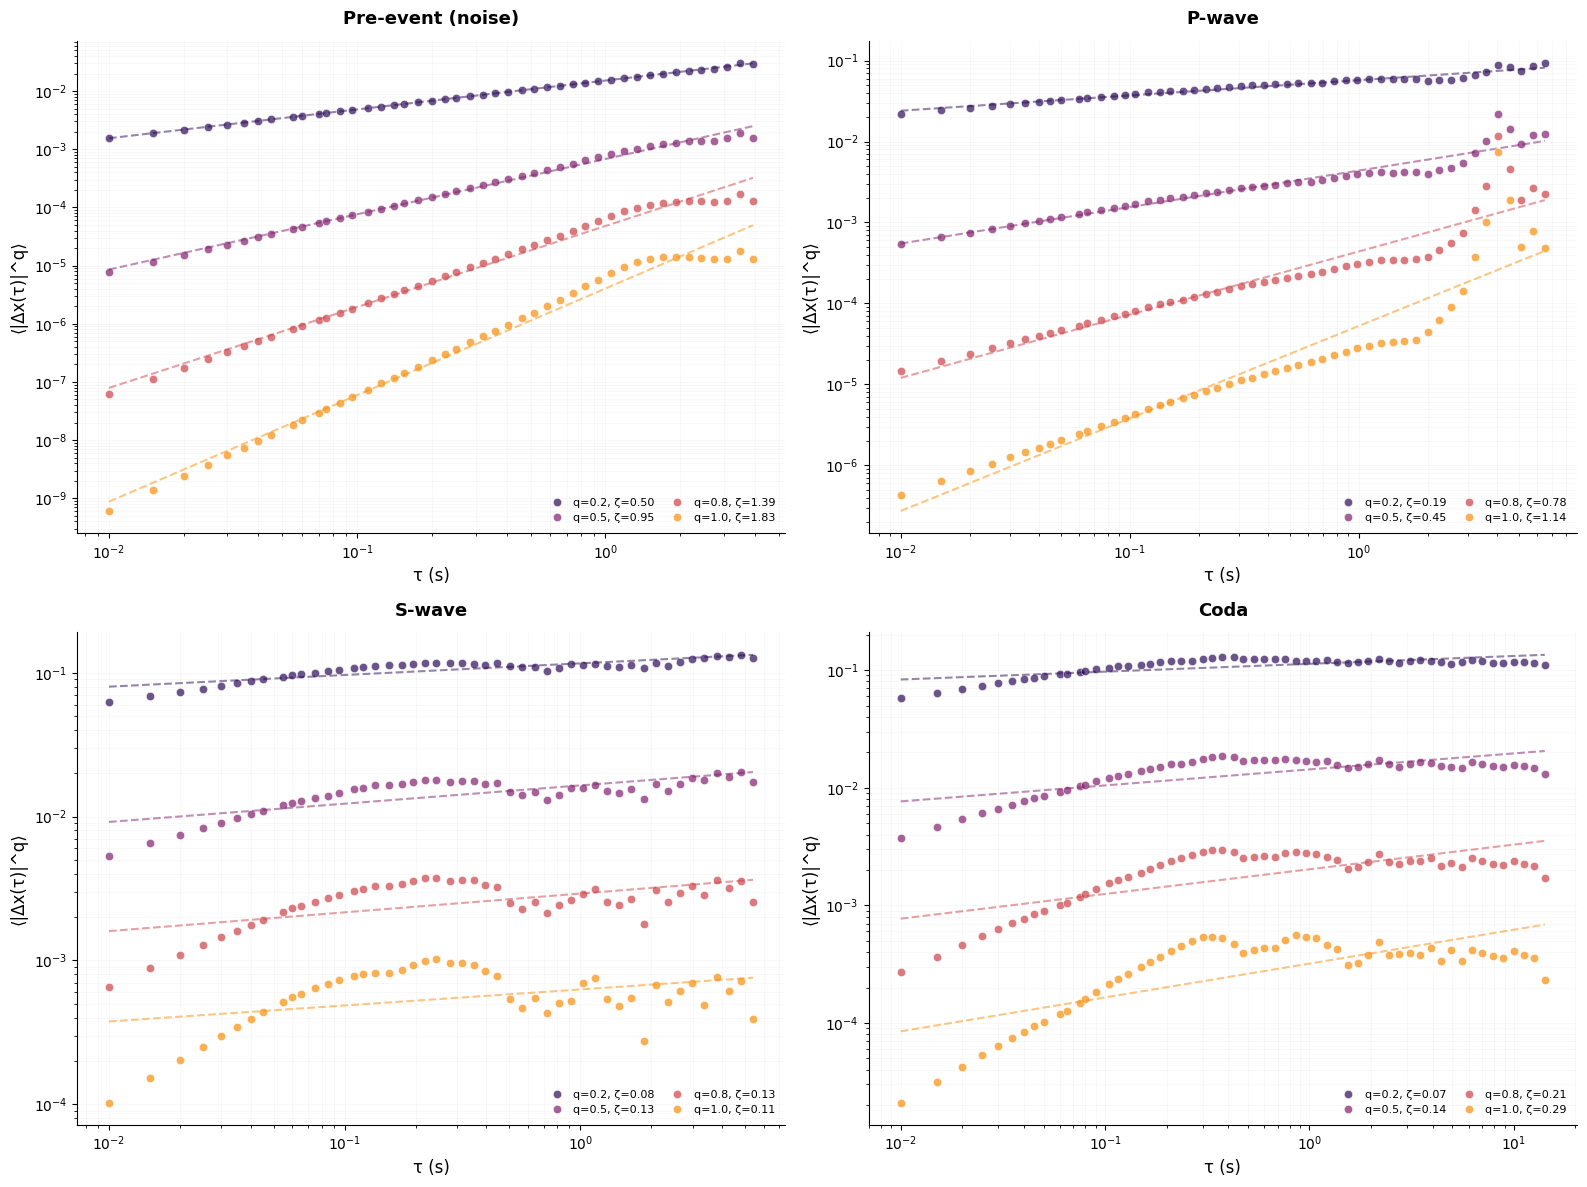

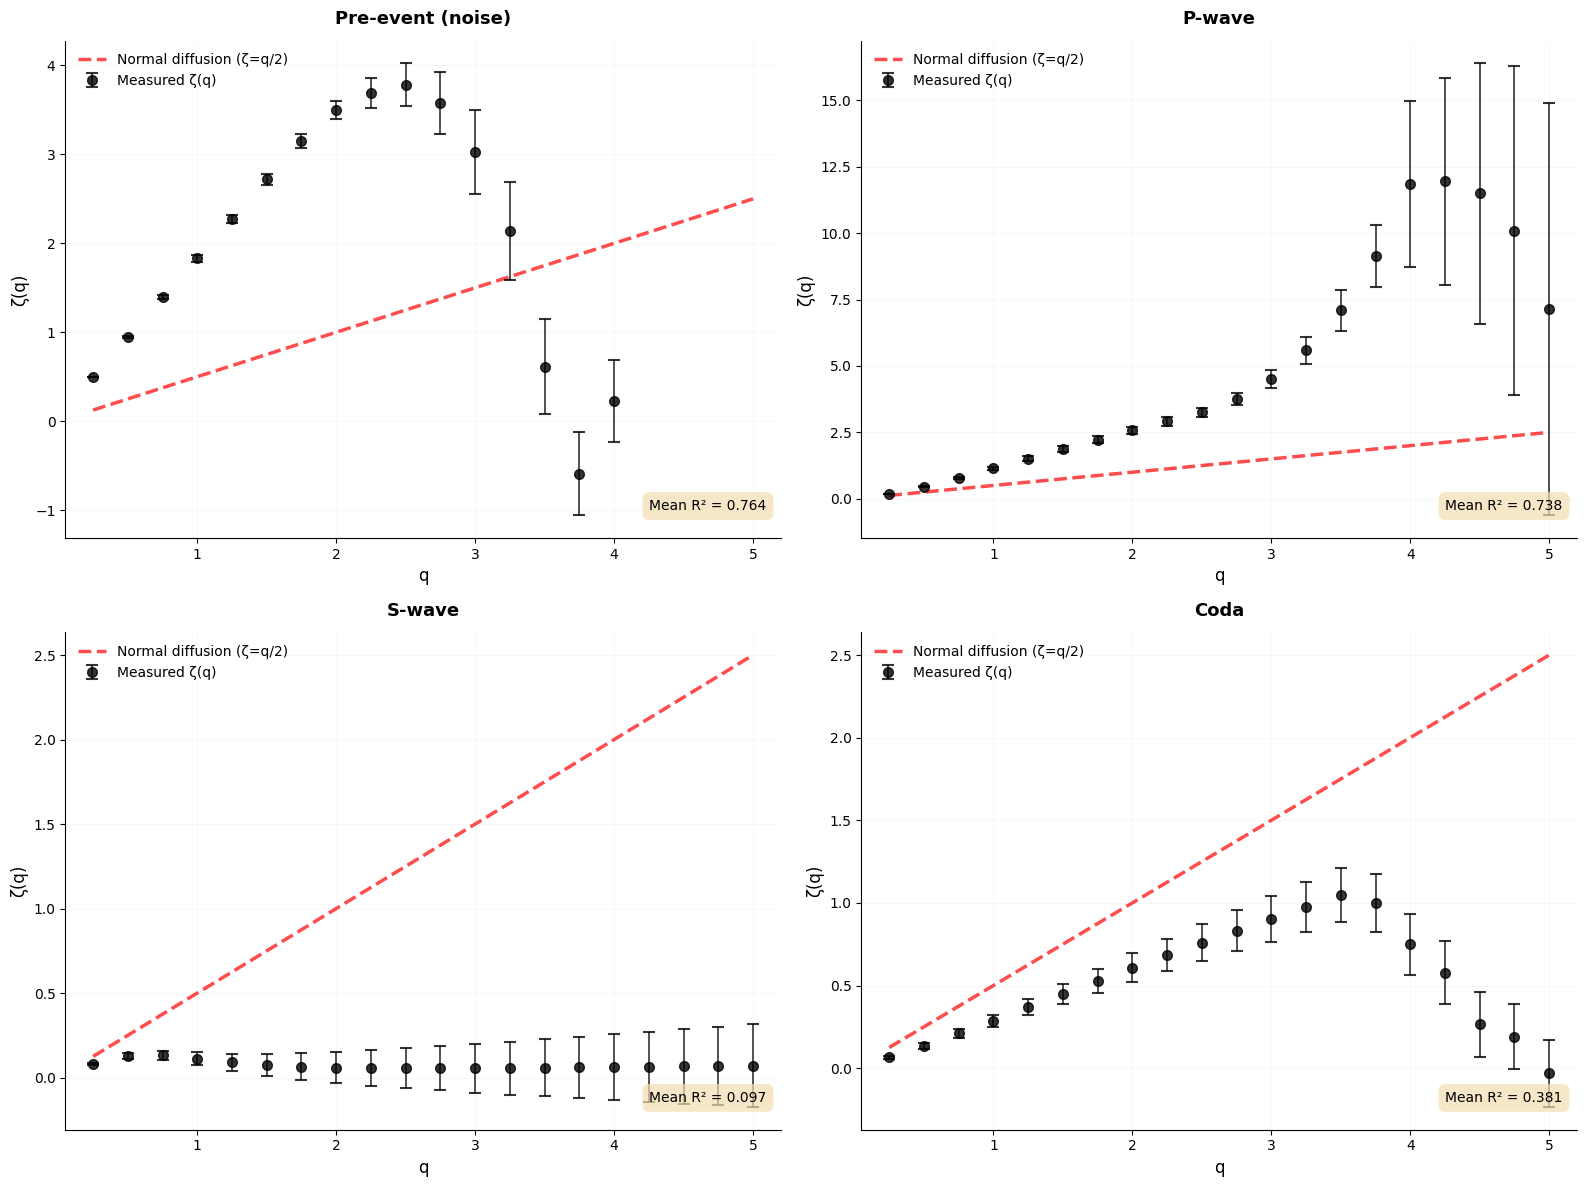

In [29]:
results_rautian = analyze_all_windows(
    windowed_signals_rautian,
    signal_field=SIGNAL_COLUMN,
    tau_min=0.01,
    n_tau=None,
    q_values=q_values,
    sampling_rate=200.0,
    fit_range=None
)

save_results_parquet(
    results_rautian, 
    output_dir=SIGNALS_PROCESSED_EXPORT / 'rautian'
)

fig1_rautian = plot_scaling_curves(
    results_rautian, 
    output_dir=FIGURES_DIR / 'rautian',
    q_subset=[0.25, 0.5, 0.75, 1]
)
fig2_rautian = plot_scaling_exponents(
    results_rautian,
    output_dir=FIGURES_DIR / 'rautian'
)

### 5.2 Arias method

ENSEMBLE SPATIAL SCALING ANALYSIS
tau_min: 0.010 s (fixed for all windows)
tau_max_fraction: None (use full window duration)
q_values: 20 values from 0.25 to 5.00
sampling_rate: 200.0 Hz

Processing window: PRE_EVENT
--------------------------------------------------------------------------------
Ensemble size: 66 signals
Tau range: [0.0100, 3.9300] s
Number of tau points: 45
Mean ζ(q): 2.0484 ± 1.3525
Mean R²: 0.7638
ζ(q=1): 1.8313
ζ(q=2): 3.4988

Processing window: P_WAVE
--------------------------------------------------------------------------------
Ensemble size: 66 signals
Tau range: [0.0100, 6.4800] s
Number of tau points: 50
Mean ζ(q): 4.9793 ± 3.9459
Mean R²: 0.7385
ζ(q=1): 1.1430
ζ(q=2): 2.5747

Processing window: S_WAVE
--------------------------------------------------------------------------------
Ensemble size: 66 signals
Tau range: [0.0100, 1.0000] s
Number of tau points: 34
Mean ζ(q): 0.5751 ± 0.2989
Mean R²: 0.2791
ζ(q=1): 0.2447
ζ(q=2): 0.4156

Processing window: CODA

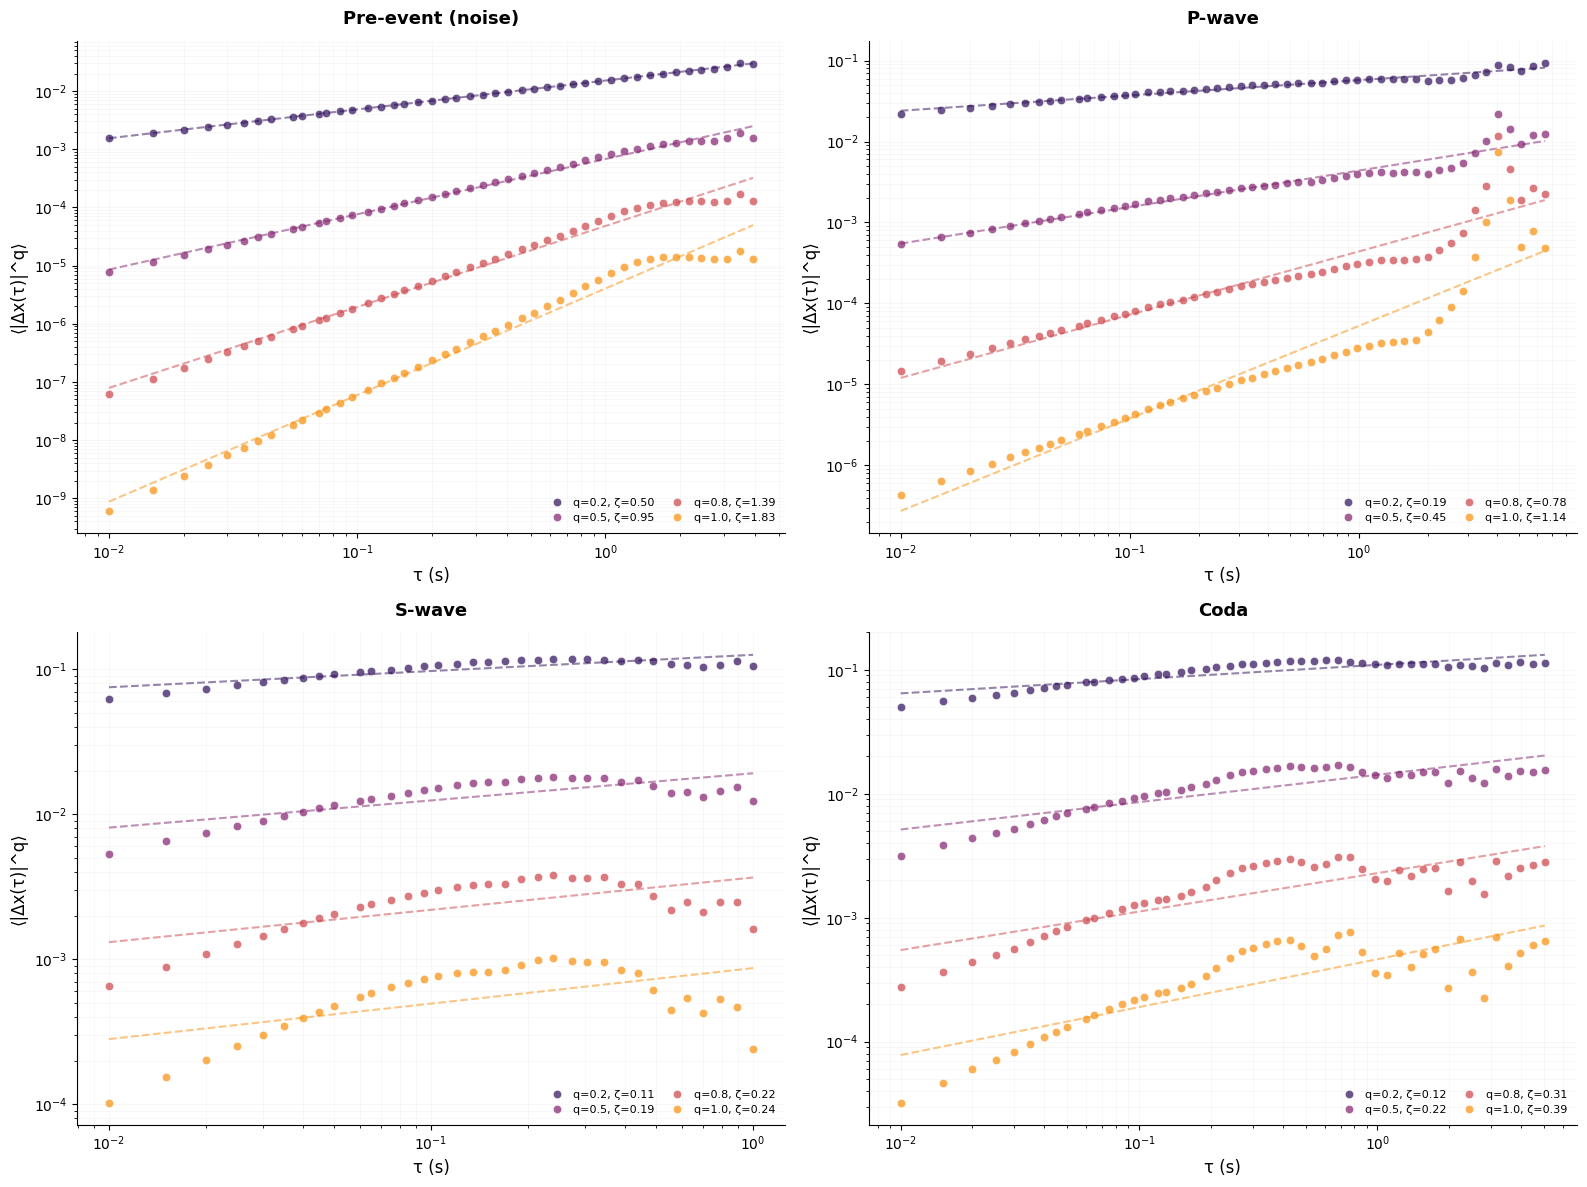

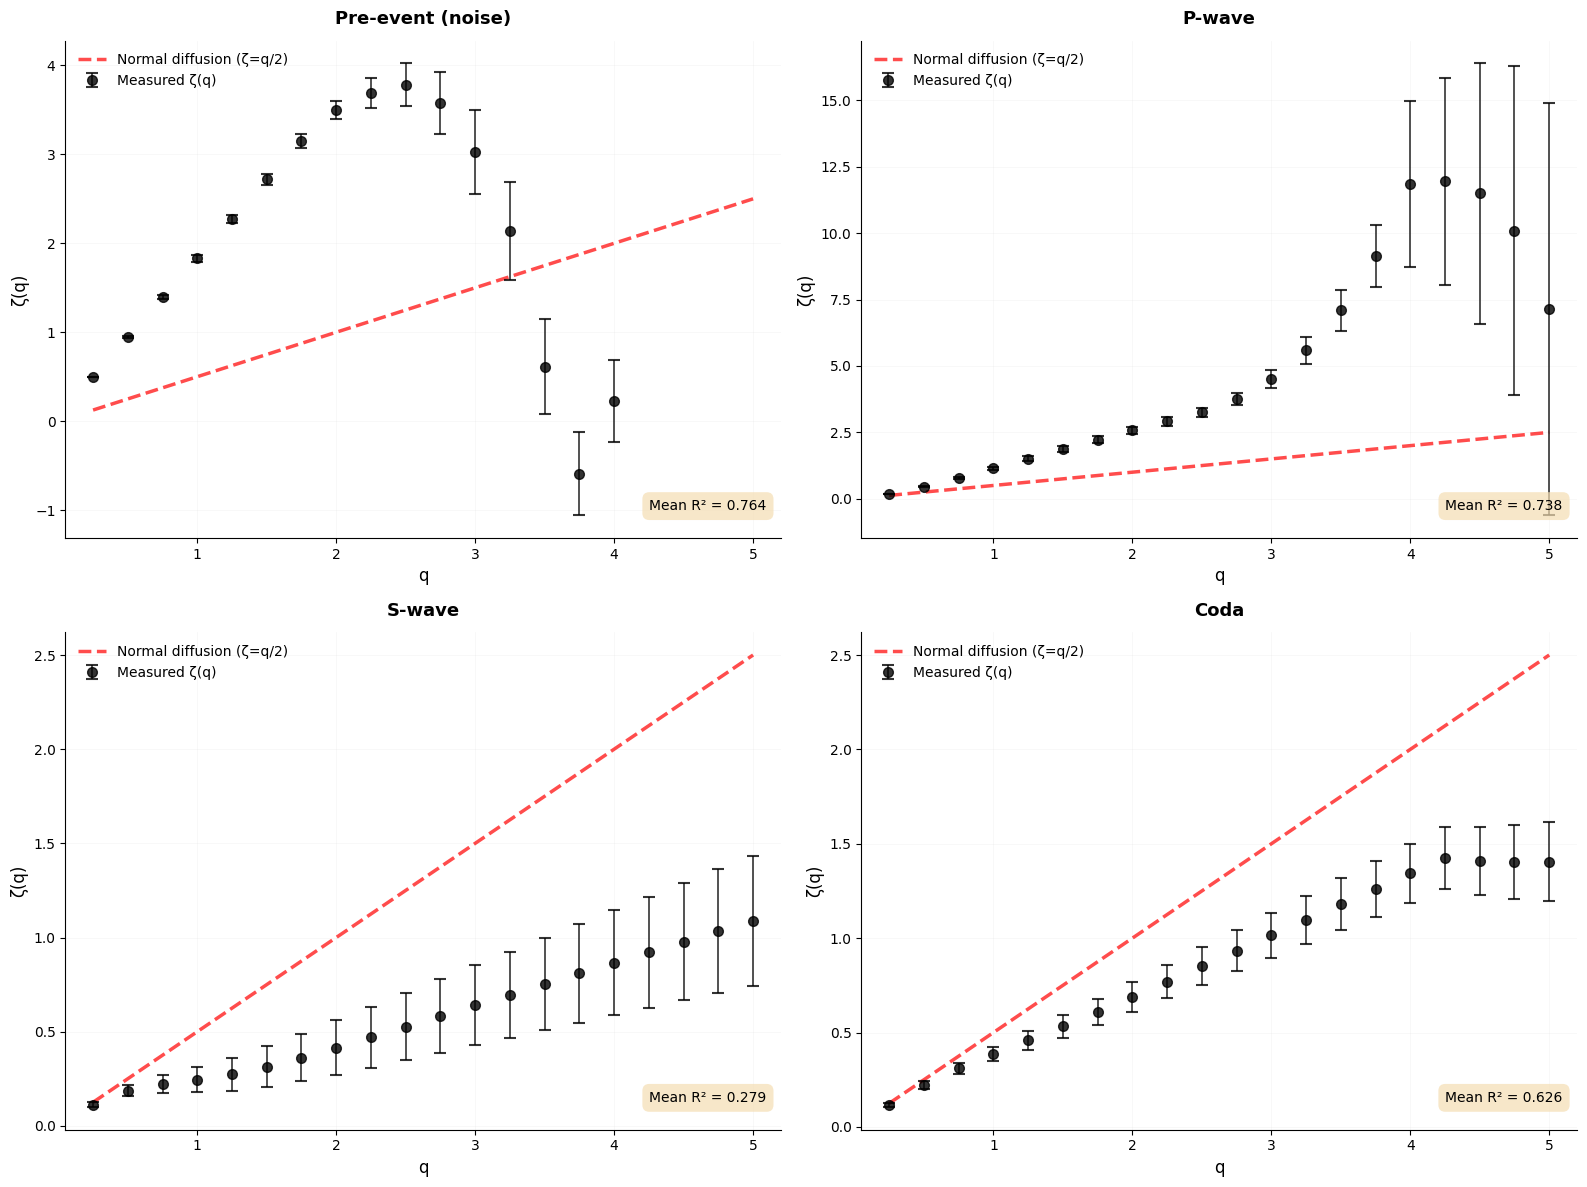

In [30]:
results_arias = analyze_all_windows(
    windowed_signals_arias,
    signal_field=SIGNAL_COLUMN,
    tau_min=0.01,
    n_tau=None,
    q_values=q_values,
    sampling_rate=200.0,
    fit_range=None
)

save_results_parquet(
    results_arias, 
    output_dir=SIGNALS_PROCESSED_EXPORT / 'arias'
)

fig1_arias = plot_scaling_curves(
    results_arias, 
    output_dir=FIGURES_DIR / 'arias',
    q_subset=[0.25, 0.5, 0.75, 1]
)
fig2_arias = plot_scaling_exponents(
    results_arias,
    output_dir=FIGURES_DIR / 'arias'
)

### 5.3 Envelope method

ENSEMBLE SPATIAL SCALING ANALYSIS
tau_min: 0.010 s (fixed for all windows)
tau_max_fraction: None (use full window duration)
q_values: 20 values from 0.25 to 5.00
sampling_rate: 200.0 Hz

Processing window: PRE_EVENT
--------------------------------------------------------------------------------
Ensemble size: 66 signals
Tau range: [0.0100, 3.9300] s
Number of tau points: 45
Mean ζ(q): 2.0484 ± 1.3525
Mean R²: 0.7638
ζ(q=1): 1.8313
ζ(q=2): 3.4988

Processing window: P_WAVE
--------------------------------------------------------------------------------
Ensemble size: 66 signals
Tau range: [0.0100, 6.4800] s
Number of tau points: 50
Mean ζ(q): 4.9793 ± 3.9459
Mean R²: 0.7385
ζ(q=1): 1.1430
ζ(q=2): 2.5747

Processing window: S_WAVE
--------------------------------------------------------------------------------
Ensemble size: 66 signals
Tau range: [0.0100, 1.0000] s
Number of tau points: 34
Mean ζ(q): 0.7214 ± 0.3866
Mean R²: 0.4301
ζ(q=1): 0.2854
ζ(q=2): 0.5292

Processing window: CODA

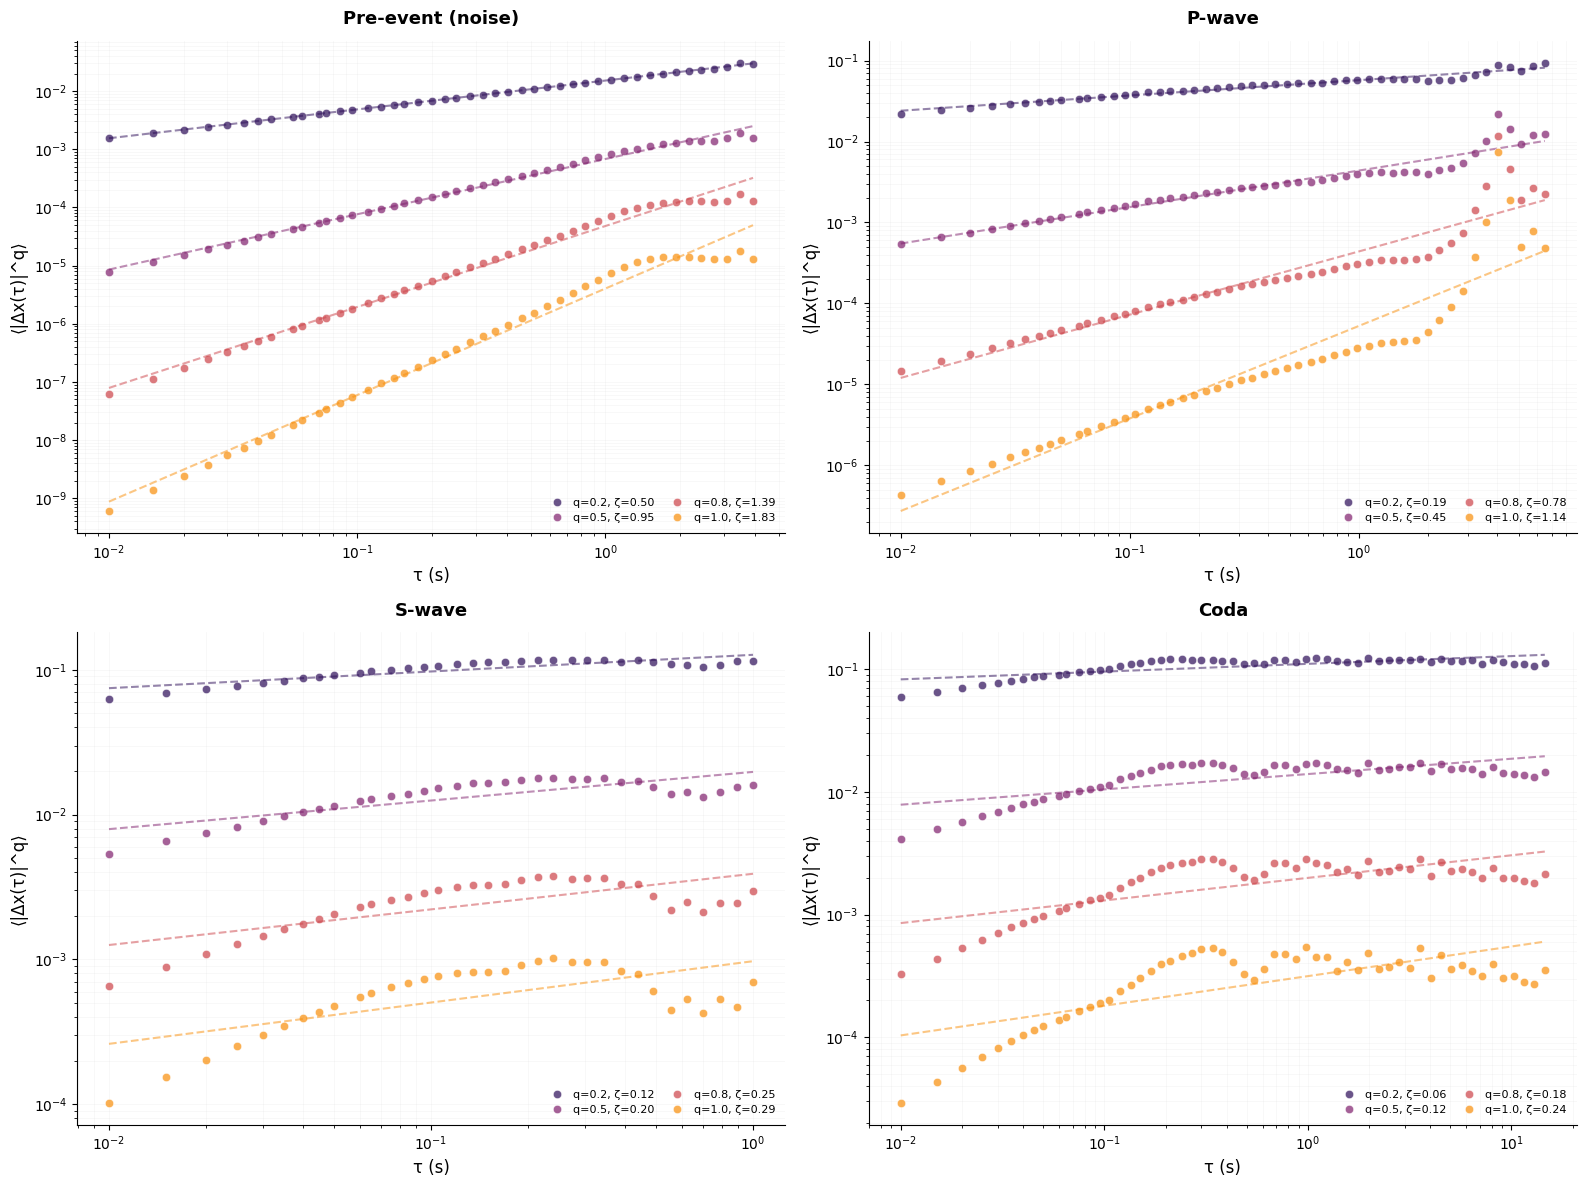

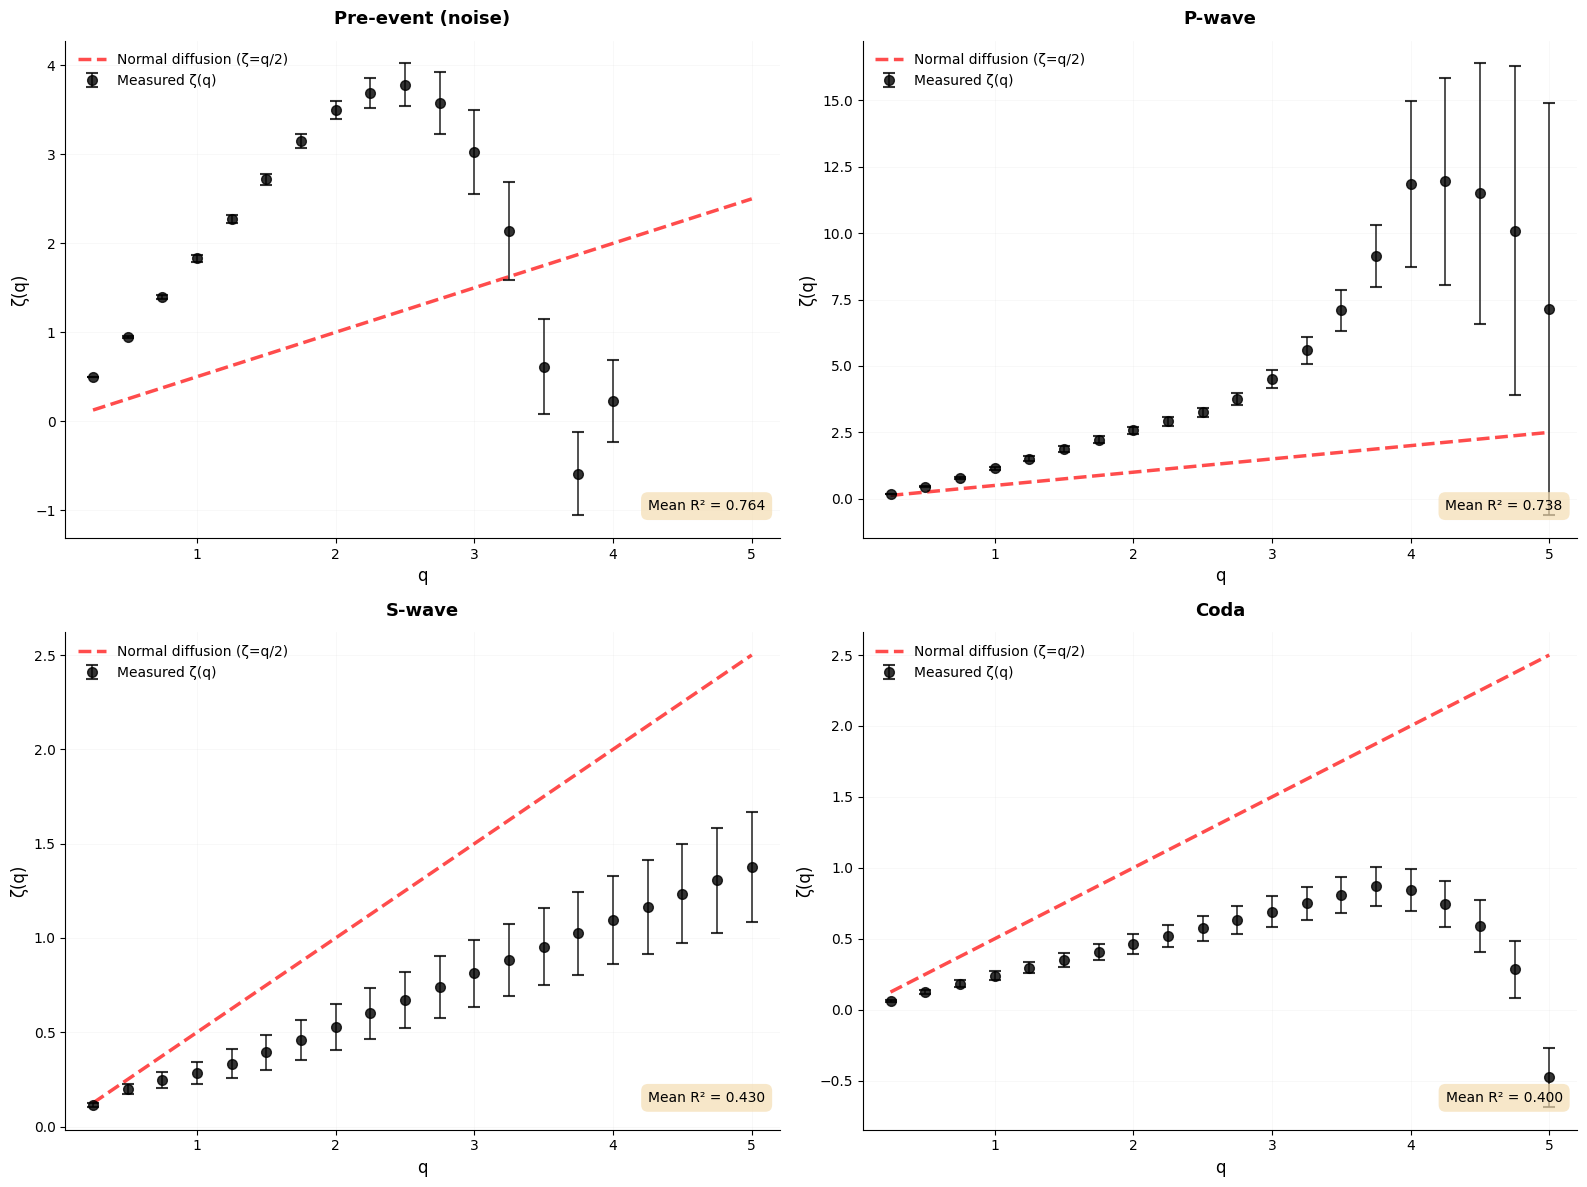

In [31]:
results_envelope = analyze_all_windows(
    windowed_signals_envelope,
    signal_field=SIGNAL_COLUMN,
    tau_min=0.01,
    n_tau=None,
    q_values=q_values,
    sampling_rate=200.0,
    fit_range=None
)

save_results_parquet(
    results_envelope, 
    output_dir=SIGNALS_PROCESSED_EXPORT / 'envelope'
)

fig1_envelope = plot_scaling_curves(
    results_envelope, 
    output_dir=FIGURES_DIR / 'envelope',
    q_subset=[0.25, 0.5, 0.75, 1]
)
fig2_envelope = plot_scaling_exponents(
    results_envelope,
    output_dir=FIGURES_DIR / 'envelope'
)

### 5.4 Median method

ENSEMBLE SPATIAL SCALING ANALYSIS
tau_min: 0.010 s (fixed for all windows)
tau_max_fraction: None (use full window duration)
q_values: 20 values from 0.25 to 5.00
sampling_rate: 200.0 Hz

Processing window: PRE_EVENT
--------------------------------------------------------------------------------
Ensemble size: 66 signals
Tau range: [0.0100, 3.9300] s
Number of tau points: 45
Mean ζ(q): 2.0484 ± 1.3525
Mean R²: 0.7638
ζ(q=1): 1.8313
ζ(q=2): 3.4988

Processing window: P_WAVE
--------------------------------------------------------------------------------
Ensemble size: 66 signals
Tau range: [0.0100, 6.4800] s
Number of tau points: 50
Mean ζ(q): 4.9793 ± 3.9459
Mean R²: 0.7385
ζ(q=1): 1.1430
ζ(q=2): 2.5747

Processing window: S_WAVE
--------------------------------------------------------------------------------
Ensemble size: 66 signals
Tau range: [0.0100, 1.6750] s
Number of tau points: 38
Mean ζ(q): 0.4834 ± 0.2476
Mean R²: 0.2854
ζ(q=1): 0.2071
ζ(q=2): 0.3552

Processing window: CODA

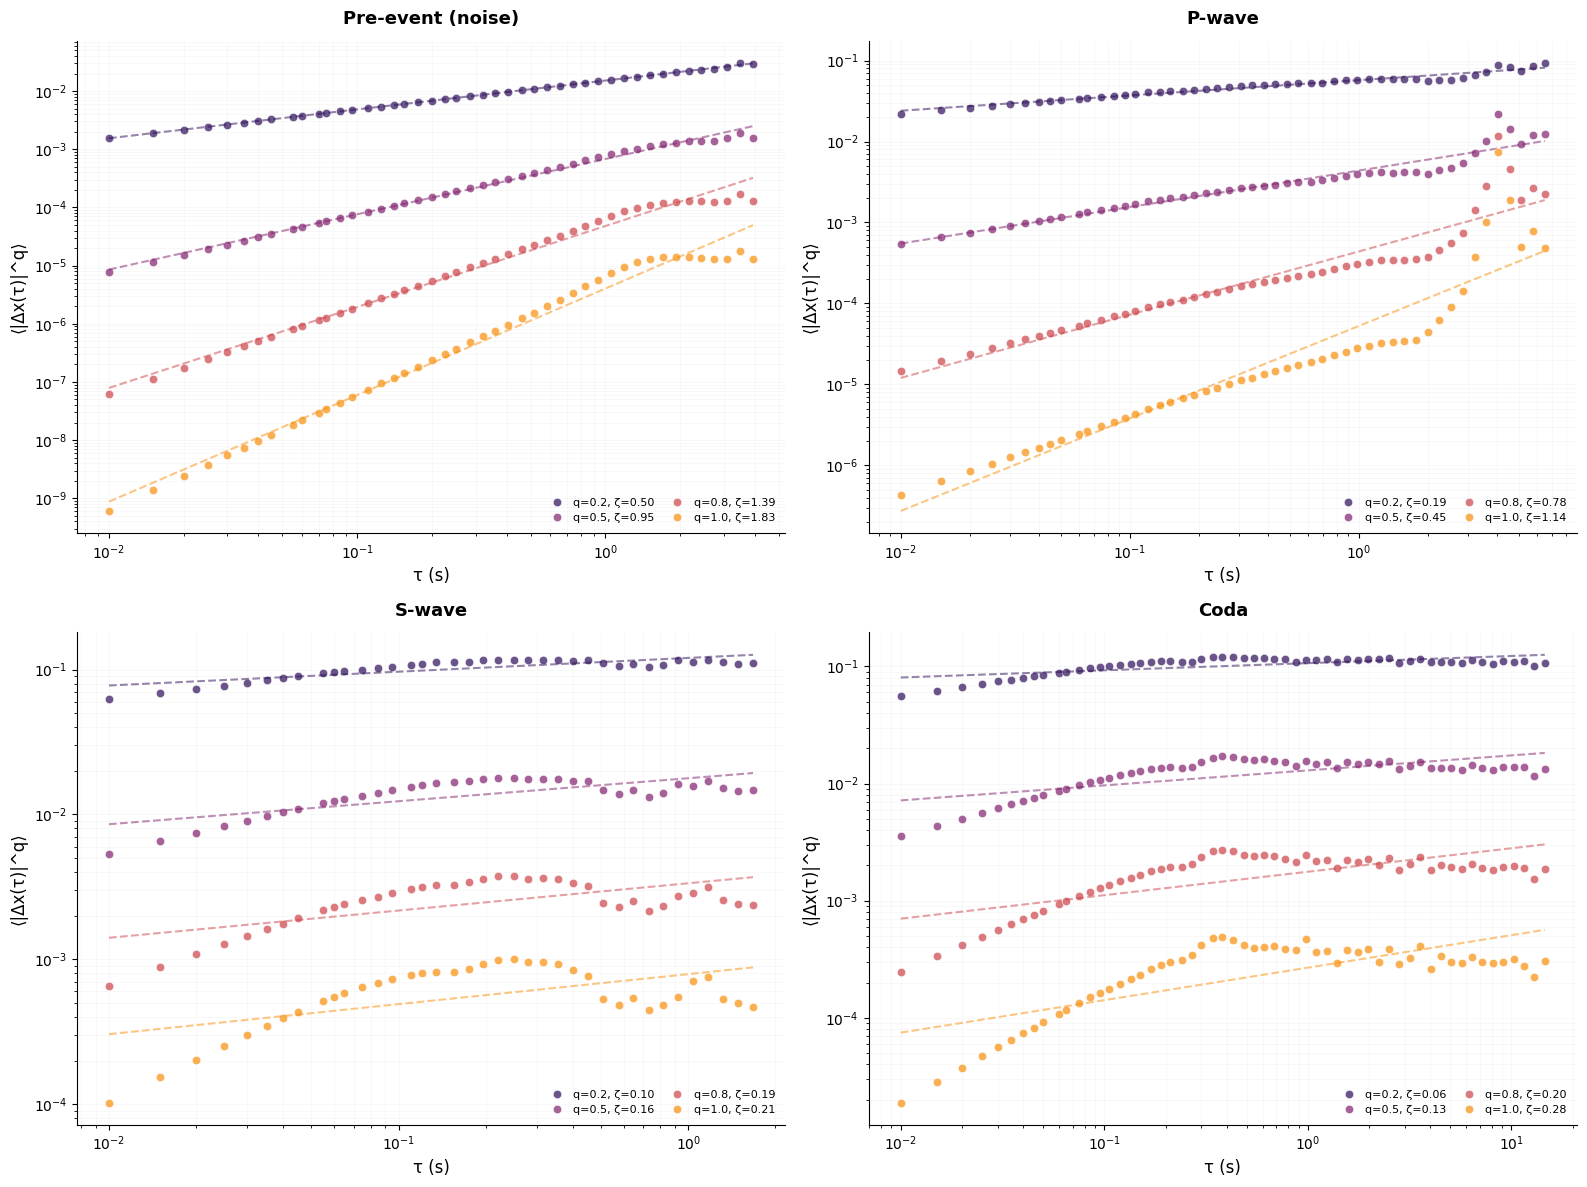

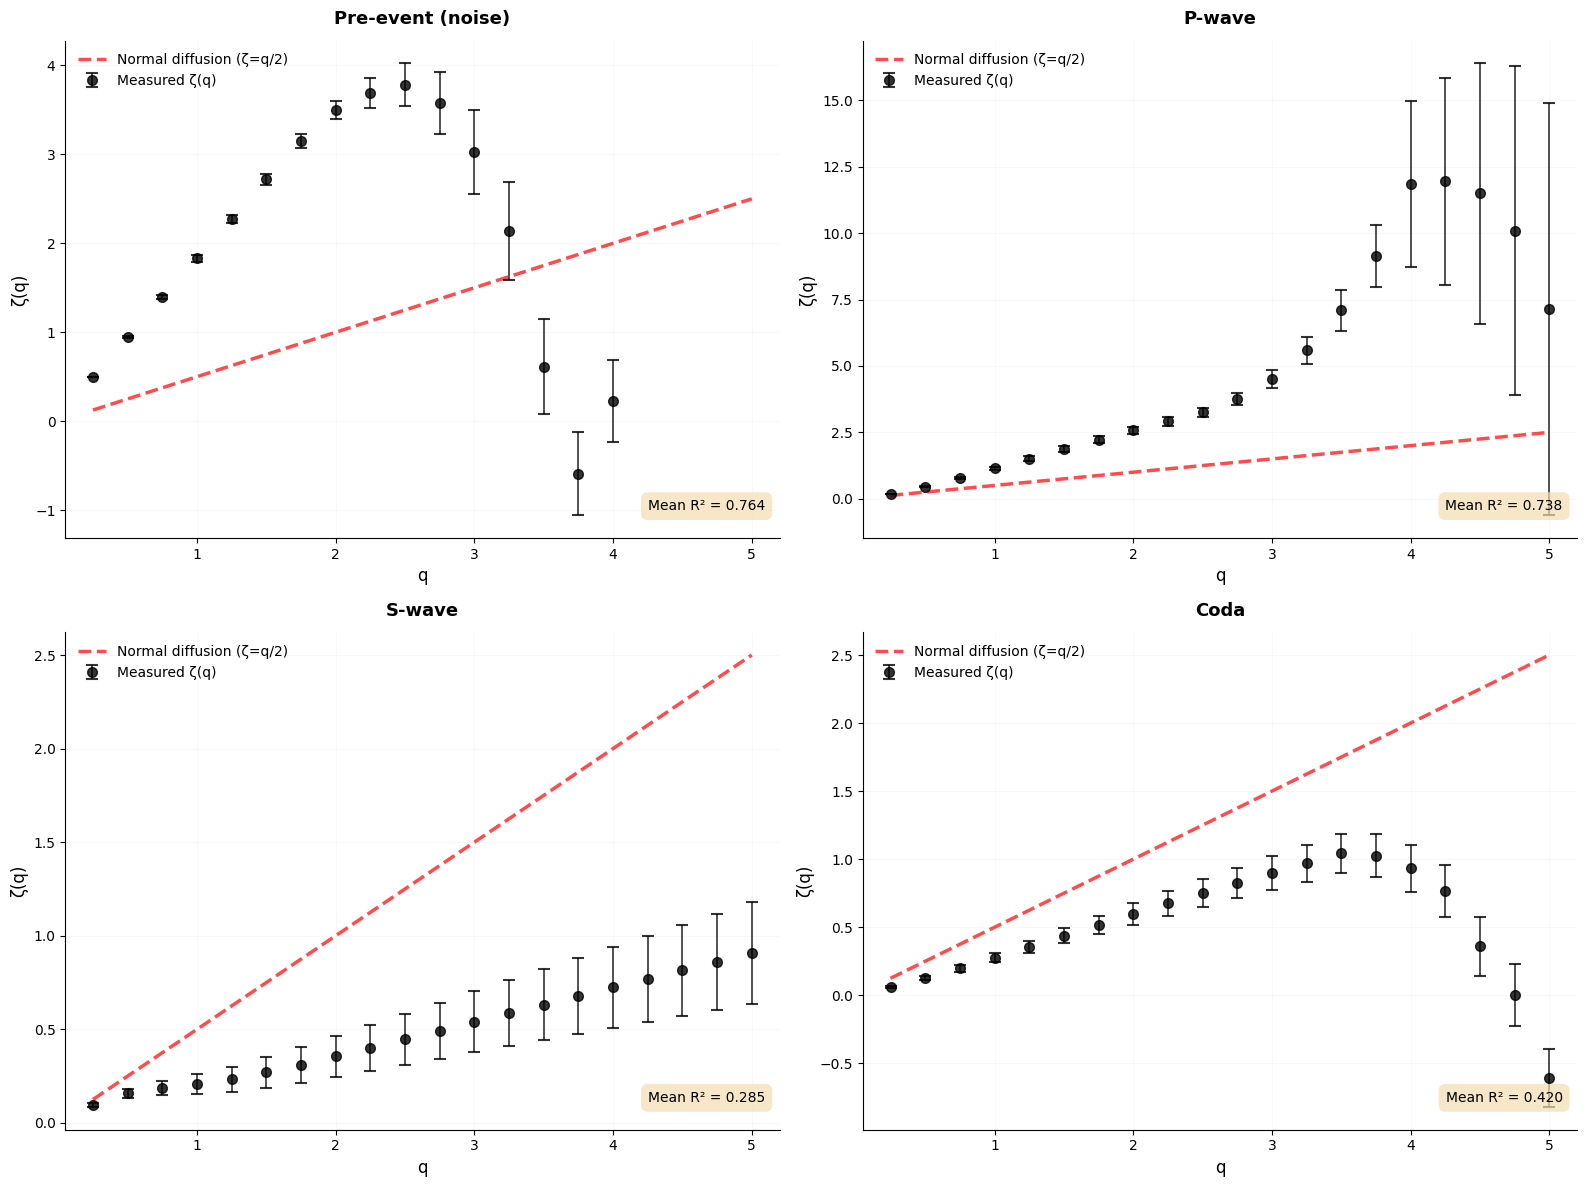

In [32]:
results_median = analyze_all_windows(
    windowed_signals_median,
    signal_field=SIGNAL_COLUMN,
    tau_min=0.01,
    n_tau=None,
    q_values=q_values,
    sampling_rate=200.0,
    fit_range=None
)

save_results_parquet(
    results_median, 
    output_dir=SIGNALS_PROCESSED_EXPORT / 'median'
)

fig1_median = plot_scaling_curves(
    results_median, 
    output_dir=FIGURES_DIR / 'median',
    q_subset=[0.25, 0.5, 0.75, 1]
)
fig2_median = plot_scaling_exponents(
    results_median,
    output_dir=FIGURES_DIR / 'median'
)

## Summary

Create summary DataFrame with key results for each window and process.